# DAS 507: Lecture 1 — 수학의 기초
### 보조 실습 노트북

강의 슬라이드의 주요 개념을 파이썬 코드로 직접 확인하고, 예제와 연습문제를 통해 이해를 심화하는 노트북입니다.

**목차**
1. [준비: 패키지 임포트 및 환경 설정](#setup)
2. [I. 수학기호](#sec1)
3. [II. 벡터와 행렬](#sec2)
4. [III. 넘파이](#sec3)
5. [IV. 함수](#sec4)

---
<a id='setup'></a>
## 준비: 패키지 임포트 및 환경 설정

In [39]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib


%matplotlib inline

### 한글 폰트 설정: 없는 경우 OS에 한글폰트(예: 나눔고딕) 설치 후 실행

In [40]:
import matplotlib.font_manager as fm
import matplotlib as mpl
# 설치된 폰트 중 "NanumGothic" 경로를 찾아 등록
font_path = None
for f in fm.findSystemFonts():
    if "NanumGothic" in f:
        font_path = f
        break

if font_path is None:
    raise RuntimeError("NanumGothic 폰트를 못 찾았어요. fonts-nanum 설치부터 확인하세요.")

fm.fontManager.addfont(font_path)
nanum_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = nanum_name
mpl.rcParams["axes.unicode_minus"] = False  # 마이너스 깨짐 방지

print("✅ Matplotlib 한글 폰트:", nanum_name)

✅ Matplotlib 한글 폰트: NanumGothicCoding


---
<a id='sec1'></a>
## I. 수학기호

### I.1 그리스 문자

데이터 과학에서 자주 등장하는 그리스 문자를 마크다운 셀에서 수식으로 표현하는 연습을 합니다.

| 기호 | LaTeX | 의미(예시) |
|------|-------|----------|
| $\alpha$ | `\alpha` | 학습률 (learning rate) |
| $\beta$ | `\beta` | 회귀 계수 |
| $\gamma$ | `\gamma` | 감마 (감쇠율 등) |
| $\delta$ | `\delta` | 작은 변화량 |
| $\epsilon$ | `\epsilon` | 오차항 |
| $\theta$ | `\theta` | 모수 (parameter) |
| $\lambda$ | `\lambda` | 정규화 계수 |
| $\mu$ | `\mu` | 평균 |
| $\sigma$ | `\sigma` | 표준편차 / 시그모이드 함수 |
| $\pi$ | `\pi` | 원주율, 혼합 비율 |
| $\Sigma$ | `\Sigma` | 합산 기호 / 공분산 행렬 |
| $\Omega$ | `\Omega` | 표본공간 |

**연습 1-1** 아래 빈 마크다운 셀에 다음 수식을 LaTeX로 직접 작성해 보세요.

1. 정규분포 확률밀도함수: $f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
2. 선형회귀 모델: $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon$
3. 경사하강법 업데이트: $\theta \leftarrow \theta - \alpha \nabla_{\theta} L(\theta)$

*(여기에 직접 LaTeX 수식을 작성해 보세요)*

### I.2 수열과 집합

- **수열(sequence)**: $N$개 숫자가 순서대로 나열된 것. $x_1, x_2, \dots, x_N$
- **집합(set)**: 순서가 중요하지 않은 원소들. $\{x_1, x_2, \dots, x_N\} =: x_{1:N} =: \{x_i\}_N$
- $\mathbb{R}$: 실수 전체의 집합, $\mathbb{R}^2 = \mathbb{R} \times \mathbb{R}$

### I.3 수열과 집합의 합과 곱

$$\sum_{i=1}^{N} x_i = x_1 + x_2 + \cdots + x_N \qquad \prod_{i=1}^{N} x_i = x_1 \cdot x_2 \cdots x_N$$

중첩 합: $\displaystyle\sum_{i=1}^{N}\left(\sum_{j=1}^{M} x_{ij}\right) = \sum_{i=1}^{N}\sum_{j=1}^{M} x_{ij}$

In [ ]:
# 예제: 합 기호 계산
# sum_{i=1}^{9} 10i = 10*1 + 10*2 + ... + 10*9

result = sum(10 * i for i in range(1, 10))
print(f"sum_{{i=1}}^{{9}} 10i = {result}")

# numpy로도 계산 가능
i_vals = np.arange(1, 10)
result_np = np.sum(10 * i_vals)
print(f"numpy 결과: {result_np}")

sum_{i=1}^{9} 10i = 450
numpy 결과: 450


In [42]:
# 예제: 중첩 합 계산
# x_{ij} = i + j 로 정의 (i=1..3, j=1..3)
# sum_{i=1}^{3} sum_{j=1}^{3} x_{ij}

X = np.array([[i + j for j in range(1, 4)] for i in range(1, 4)])
print("행렬 X (x_ij = i+j):")
print(X)
print(f"\n이중 합 결과: {np.sum(X)}")
print(f"행별 합 먼저 후 전체 합: {np.sum(np.sum(X, axis=1))}")

행렬 X (x_ij = i+j):
[[2 3 4]
 [3 4 5]
 [4 5 6]]

이중 합 결과: 36
행별 합 먼저 후 전체 합: 36


In [43]:
# 예제: 곱 기호 — 0이 아닌 원소만 곱하기
x = np.array([3.0, 0.0, 2.0, 5.0, 0.0, 4.0])
A = {xi for xi in x}  # 집합

# x ∈ A, x ≠ 0 인 원소들의 곱
nonzero_x = x[x != 0]
product = np.prod(nonzero_x)
print(f"배열 x = {x}")
print(f"0이 아닌 원소: {nonzero_x}")
print(f"0이 아닌 원소들의 곱: {product}")

배열 x = [3. 0. 2. 5. 0. 4.]
0이 아닌 원소: [3. 2. 5. 4.]
0이 아닌 원소들의 곱: 120.0


---
### 연습문제 1-A: 합과 곱 기호 전개

다음 수식을 파이썬 코드로 계산하고, 손으로 전개한 결과와 비교하세요.

1. **(서포트 벡터 머신 모형)** $\displaystyle\sum_{i=1}^{3}\sum_{j=1}^{3} a_i a_j y_i y_j x_i x_j$  
   (단, $a = [1, 2, 3]$, $y = [1, -1, 1]$, $x = [2, 3, 4]$)

2. **(카테고리 분포)** $\displaystyle\prod_{i=1}^{4}\prod_{k=1}^{4} \theta_k^{x_{i,k}}$  
   (단, $\theta = [0.1, 0.3, 0.4, 0.2]$, $X$는 4×4 행렬에서 각 행이 one-hot 벡터)

In [44]:
# 연습문제 1-A.1: SVM 모형 이중 합
a = np.array([1, 2, 3])
y = np.array([1, -1, 1])
x = np.array([2, 3, 4])

# for 루프로 계산
total_loop = 0
for i in range(3):
    for j in range(3):
        total_loop += a[i] * a[j] * y[i] * y[j] * x[i] * x[j]
print(f"루프 계산: {total_loop}")

# numpy 벡터화 계산 (외적 이용)
ay = a * y * x  # a_i * y_i * x_i
total_np = np.sum(np.outer(ay, ay))
print(f"numpy 계산: {total_np}")
print(f"두 결과가 같은가: {total_loop == total_np}")

루프 계산: 64
numpy 계산: 64
두 결과가 같은가: True


In [45]:
# 연습문제 1-A.2: 카테고리 분포 곱
theta = np.array([0.1, 0.3, 0.4, 0.2])

# 4개 관측치의 one-hot 인코딩 (각 관측이 어떤 카테고리인지)
X_onehot = np.array([
    [1, 0, 0, 0],  # 관측 1: 카테고리 1
    [0, 1, 0, 0],  # 관측 2: 카테고리 2
    [0, 0, 1, 0],  # 관측 3: 카테고리 3
    [0, 1, 0, 0],  # 관측 4: 카테고리 2
])

# prod_{i=1}^{4} prod_{k=1}^{4} theta_k^{x_{i,k}}
result = np.prod(theta ** X_onehot)
print(f"카테고리 분포 확률 곱: {result:.6f}")

# 로그를 이용한 계산
log_result = np.sum(X_onehot * np.log(theta))
print(f"로그 합 (log-likelihood): {log_result:.6f}")
print(f"exp(log_result) = {np.exp(log_result):.6f}")

카테고리 분포 확률 곱: 0.003600
로그 합 (log-likelihood): -5.626821
exp(log_result) = 0.003600


---
### 연습문제 1-B: 항등식 증명 (수치 검증)

다음 두 항등식이 성립함을 수치적으로 확인하세요.

1. $\displaystyle\left(\sum_{i=1}^{3} x_i\right)^2 = \sum_{i=1}^{3}\sum_{j=1}^{3} x_i x_j$

2. $\displaystyle\sum_{i=1}^{3}\sum_{j=1}^{3} x_i y_{ij} = \sum_{i=1}^{3}\left(x_i \sum_{j=1}^{3} y_{ij}\right)$

In [46]:
# 연습문제 1-B.1
x = np.array([2.0, 5.0, -1.0])

lhs = (np.sum(x)) ** 2
rhs = np.sum(np.outer(x, x))  # x_i * x_j 의 이중 합

print(f"좌변: (sum xi)^2 = {lhs}")
print(f"우변: sum_i sum_j xi*xj = {rhs}")
print(f"항등식 성립: {np.isclose(lhs, rhs)}")

좌변: (sum xi)^2 = 36.0
우변: sum_i sum_j xi*xj = 36.0
항등식 성립: True


In [47]:
# 연습문제 1-B.2
x = np.array([1.0, 3.0, 2.0])
Y = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=float)

# 좌변: sum_i sum_j x_i * y_{ij}
lhs = np.sum(x[:, np.newaxis] * Y)

# 우변: sum_i x_i * (sum_j y_{ij})
row_sums = np.sum(Y, axis=1)  # sum_j y_{ij}
rhs = np.sum(x * row_sums)

print(f"좌변: {lhs}")
print(f"우변: {rhs}")
print(f"항등식 성립: {np.isclose(lhs, rhs)}")

좌변: 99.0
우변: 99.0
항등식 성립: True


---
<a id='sec2'></a>
## II. 벡터와 행렬

### II.1 데이터의 유형

| 유형 | 설명 | 예시 |
|------|------|------|
| **스칼라** | 숫자 하나 $x \in \mathbb{R}$ | 체온: 36.5 |
| **벡터** | $N$차원 수 배열 $x \in \mathbb{R}^N$ | 키, 몸무게, 나이 등 여러 특징 |
| **행렬** | $N \times p$ 데이터 집합 $X \in \mathbb{R}^{N \times p}$ | 150명 × 4특징 (Iris 데이터) |
| **텐서** | 같은 크기 행렬이 여러 개 | 컬러 이미지 (높이 × 폭 × 채널) |

In [48]:
# Iris 데이터 불러오기 및 구조 확인
from sklearn.datasets import load_iris
iris = load_iris()

X = iris.data   # 행렬: (150, 4)
y = iris.target  # 벡터: (150,)

print(f"데이터 행렬 X의 형태: {X.shape}  → {X.shape[0]}개 샘플, {X.shape[1]}개 특징")
print(f"레이블 벡터 y의 형태: {y.shape}")
print(f"\n첫 번째 꽃의 특징 벡터: {X[0]}")
print(f"특징 이름: {iris.feature_names}")
print(f"클래스: {iris.target_names}")

데이터 행렬 X의 형태: (150, 4)  → 150개 샘플, 4개 특징
레이블 벡터 y의 형태: (150,)

첫 번째 꽃의 특징 벡터: [5.1 3.5 1.4 0.2]
특징 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
클래스: ['setosa' 'versicolor' 'virginica']


이미지 텐서 형태: (768, 1024, 3)
  → 세로: 768픽셀, 가로: 1024픽셀, 채널 수: 3 (RGB)


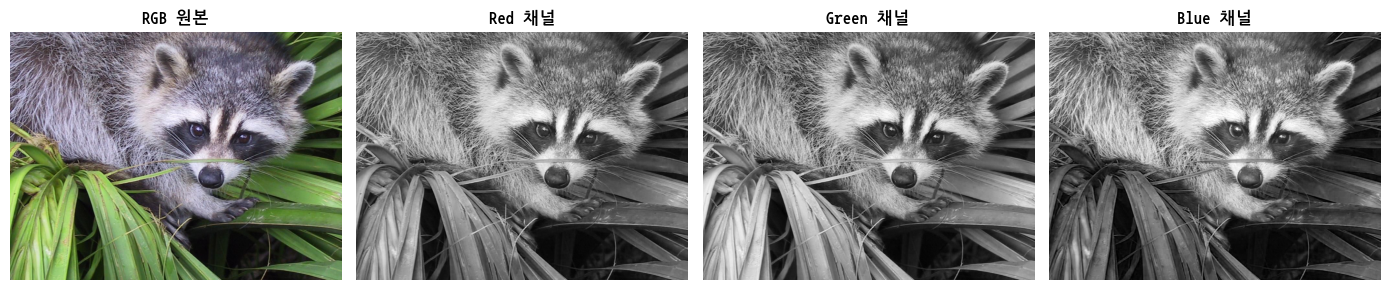

In [49]:
# 컬러 이미지 = 3차원 텐서 예시
from scipy import datasets
img = datasets.face()  # 768 × 1024 × 3

print(f"이미지 텐서 형태: {img.shape}")
print(f"  → 세로: {img.shape[0]}픽셀, 가로: {img.shape[1]}픽셀, 채널 수: {img.shape[2]} (RGB)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
titles = ['RGB 원본', 'Red 채널', 'Green 채널', 'Blue 채널']
images = [img, img[:,:,0], img[:,:,1], img[:,:,2]]
for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

### II.2 전치 연산

행렬의 행과 열을 바꾸는 연산: $X \in \mathbb{R}^{N \times p} \Rightarrow X^T \in \mathbb{R}^{p \times N}$

In [50]:
# 전치 연산 예제
A = np.array([[11, 12, 13],
              [21, 22, 23]])
print(f"A의 형태: {A.shape}")
print("A =\n", A)
print(f"\nA^T의 형태: {A.T.shape}")
print("A^T =\n", A.T)

A의 형태: (2, 3)
A =
 [[11 12 13]
 [21 22 23]]

A^T의 형태: (3, 2)
A^T =
 [[11 21]
 [12 22]
 [13 23]]


In [51]:
# 1D 벡터 vs 2D 열벡터의 전치 비교
x1d = np.array([5.1, 3.5, 1.4, 0.2])          # 1D: shape (4,)
x2d = np.array([[5.1], [3.5], [1.4], [0.2]])   # 2D 열벡터: shape (4,1)

print(f"1D 벡터 x1d.shape = {x1d.shape},  x1d.T.shape = {x1d.T.shape}  ← 전치해도 변화 없음!")
print(f"2D 열벡터 x2d.shape = {x2d.shape},  x2d.T.shape = {x2d.T.shape}  ← 행벡터가 됨")

1D 벡터 x1d.shape = (4,),  x1d.T.shape = (4,)  ← 전치해도 변화 없음!
2D 열벡터 x2d.shape = (4, 1),  x2d.T.shape = (1, 4)  ← 행벡터가 됨


### II.3 특수한 벡터와 행렬

In [52]:
print("영벡터 (3×1):")
print(np.zeros((3, 1)))

print("\n일벡터 (3×1):")
print(np.ones((3, 1)))

print("\n대각행렬 diag(1, 2, 3):")
print(np.diag([1, 2, 3]))

print("\n3×3 항등행렬:")
print(np.identity(3))

영벡터 (3×1):
[[0.]
 [0.]
 [0.]]

일벡터 (3×1):
[[1.]
 [1.]
 [1.]]

대각행렬 diag(1, 2, 3):
[[1 0 0]
 [0 2 0]
 [0 0 3]]

3×3 항등행렬:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [53]:
# 대칭행렬 확인: S = S^T
S = np.array([[4, 2, 1],
              [2, 5, 3],
              [1, 3, 6]])
print("S =\n", S)
print(f"\n대칭행렬인가 (S == S^T): {np.array_equal(S, S.T)}")

S =
 [[4 2 1]
 [2 5 3]
 [1 3 6]]

대칭행렬인가 (S == S^T): True


**연습 2-1** 아래 행렬 $A$에 대해 $AA^T$와 $A^TA$를 계산하고,
각각이 대칭행렬인지 확인하세요. 두 결과의 크기(shape)도 비교해 보세요.

In [54]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])

AAT = A @ A.T  # A*A^T
ATA = A.T @ A  # A^T*A

print(f"A의 형태: {A.shape}")
print(f"AA^T의 형태: {AAT.shape}")
print(f"A^TA의 형태: {ATA.shape}")
print("\nAA^T =\n", AAT)
print(f"AA^T 대칭행렬인가: {np.array_equal(AAT, AAT.T)}")
print("\nA^TA =\n", ATA)
print(f"A^TA 대칭행렬인가: {np.array_equal(ATA, ATA.T)}")

A의 형태: (2, 3)
AA^T의 형태: (2, 2)
A^TA의 형태: (3, 3)

AA^T =
 [[14 32]
 [32 77]]
AA^T 대칭행렬인가: True

A^TA =
 [[17 22 27]
 [22 29 36]
 [27 36 45]]
A^TA 대칭행렬인가: True


---
<a id='sec3'></a>
## III. 넘파이(NumPy)

### III.1 왜 넘파이인가? — 속도 비교

In [55]:
n = 1_000_000
w = [np.random.random() for _ in range(n)]
x = [np.random.random() for _ in range(n)]
wnum = np.array(w)
xnum = np.array(x)

print("=== for 루프 ===")
%timeit -n 3 sum(w[i]*x[i] for i in range(n))

print("\n=== numpy dot ===")
%timeit -n 3 np.dot(wnum, xnum)

=== for 루프 ===
69.3 ms ± 671 μs per loop (mean ± std. dev. of 7 runs, 3 loops each)

=== numpy dot ===
3.09 ms ± 218 μs per loop (mean ± std. dev. of 7 runs, 3 loops each)


### III.2 배열의 속성

In [56]:
# 여러 차원의 배열 속성 비교
arrays = {
    "1D (3,)": np.array([1, 2, 3]),
    "2D (2,3)": np.arange(6).reshape(2, 3),
    "3D (2,3,4)": np.arange(24).reshape(2, 3, 4),
}

for name, arr in arrays.items():
    print(f"[{name}]")
    print(f"  ndim={arr.ndim}, shape={arr.shape}, size={arr.size}, dtype={arr.dtype}")

[1D (3,)]
  ndim=1, shape=(3,), size=3, dtype=int64
[2D (2,3)]
  ndim=2, shape=(2, 3), size=6, dtype=int64
[3D (2,3,4)]
  ndim=3, shape=(2, 3, 4), size=24, dtype=int64


### III.3 배열 생성 함수

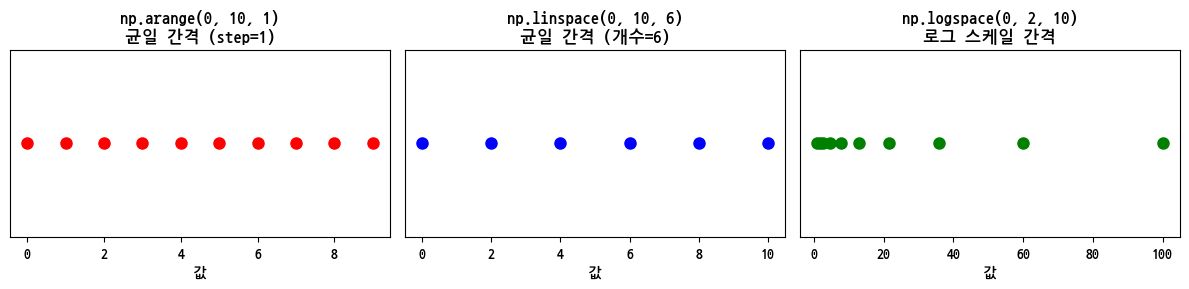

linspace 값: [ 0.  2.  4.  6.  8. 10.]
logspace 값: [  1.     1.67   2.78   4.64   7.74  12.92  21.54  35.94  59.95 100.  ]


In [57]:
# arange / linspace / logspace 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# arange: 간격 지정
a = np.arange(0, 10, 1)
axes[0].plot(a, np.zeros_like(a), 'or', ms=8)
axes[0].set_title('np.arange(0, 10, 1)\n균일 간격 (step=1)')
axes[0].set_yticks([])
axes[0].set_xlabel('값')

# linspace: 개수 지정
b = np.linspace(0, 10, 6)  # 6개
axes[1].plot(b, np.zeros_like(b), 'ob', ms=8)
axes[1].set_title('np.linspace(0, 10, 6)\n균일 간격 (개수=6)')
axes[1].set_yticks([])
axes[1].set_xlabel('값')

# logspace: 로그 스케일
c = np.logspace(0, 2, 10)  # 10^0 ~ 10^2
axes[2].plot(c, np.zeros_like(c), 'og', ms=8)
axes[2].set_title('np.logspace(0, 2, 10)\n로그 스케일 간격')
axes[2].set_yticks([])
axes[2].set_xlabel('값')

plt.tight_layout()
plt.show()

print(f"linspace 값: {b}")
print(f"logspace 값: {np.round(c, 2)}")

### III.4 인덱싱과 슬라이싱

In [58]:
# 3×4 행렬 A 생성
#  [[ 1  2  3  4]
#   [ 5  6  7  8]
#   [ 9 10 11 12]]

A = np.arange(1, 13).reshape(3, 4)
print("행렬 A =\n", A)
print()

print(f"원소 7: A[1,2] = {A[1,2]}")
print(f"원소 12: A[2,3] = {A[2,3]}")
print(f"마지막 원소: A[-1,-1] = {A[-1,-1]}")
print(f"마지막 행: A[-1] = {A[-1]}")
print(f"첫 번째 열: A[:,0] = {A[:,0]}")
print(f"마지막 열: A[:,-1] = {A[:,-1]}")
print(f"위 왼쪽 2×2:\n{A[:2,:2]}")
print(f"아래 오른쪽 2×2:\n{A[-2:,-2:]}")
print(f"첫 2열:\n{A[:,:2]}")

행렬 A =
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

원소 7: A[1,2] = 7
원소 12: A[2,3] = 12
마지막 원소: A[-1,-1] = 12
마지막 행: A[-1] = [ 9 10 11 12]
첫 번째 열: A[:,0] = [1 5 9]
마지막 열: A[:,-1] = [ 4  8 12]
위 왼쪽 2×2:
[[1 2]
 [5 6]]
아래 오른쪽 2×2:
[[ 7  8]
 [11 12]]
첫 2열:
[[ 1  2]
 [ 5  6]
 [ 9 10]]


**연습 3-1: 슬라이싱 퀴즈**

아래 5×5 행렬 B에서 색칠된 부분을 슬라이싱으로 추출하세요.

```
B = [[ 1  2  3  4  5]
     [ 6  7  8  9 10]
     [11 12 13 14 15]
     [16 17 18 19 20]
     [21 22 23 24 25]]
```

1. 가운데 3×3 부분 추출 → `[[7,8,9],[12,13,14],[17,18,19]]`
2. 짝수 번째 행만 추출 (0, 2, 4행) → `[[1..5],[11..15],[21..25]]`
3. 대각 원소 추출 → `[1, 7, 13, 19, 25]`

In [59]:
B = np.arange(1, 26).reshape(5, 5)
print("B =\n", B)

# 1. 가운데 3×3
center = B[1:4, 1:4]
print("\n1. 가운데 3×3:\n", center)

# 2. 짝수 번째 행
even_rows = B[::2, :]
print("\n2. 짝수 번째 행 (0, 2, 4행):\n", even_rows)

# 3. 대각 원소
diag_elements = np.diag(B)
print("\n3. 대각 원소:", diag_elements)

B =
 [[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

1. 가운데 3×3:
 [[ 7  8  9]
 [12 13 14]
 [17 18 19]]

2. 짝수 번째 행 (0, 2, 4행):
 [[ 1  2  3  4  5]
 [11 12 13 14 15]
 [21 22 23 24 25]]

3. 대각 원소: [ 1  7 13 19 25]


### III.5 서브배열(Subarray)과 복사(Copy)

> **중요**: 슬라이싱은 **view**를 반환 — 원본과 같은 메모리를 공유!  
> 독립적인 배열이 필요하면 `.copy()` 사용

In [60]:
# 슬라이싱 = 뷰 (원본 변경됨)
a = np.arange(1, 13).reshape(3, 4)
print("원본 a:\n", a)

b = a[:2, :2]  # 서브배열 (뷰)
b[0, 0] = 999  # b를 수정하면 a도 변경!
print("\nb[0,0] = 999 으로 수정 후 원본 a:\n", a)
print("b와 a가 같은 메모리를 공유하는가:", np.shares_memory(a, b))

원본 a:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

b[0,0] = 999 으로 수정 후 원본 a:
 [[999   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]
b와 a가 같은 메모리를 공유하는가: True


In [61]:
# .copy() = 독립적인 복사본
a = np.arange(1, 13).reshape(3, 4)
c = a[:2, :2].copy()  # 독립 복사
c[0, 0] = 999         # c를 수정해도 a는 변경되지 않음
print("c[0,0] = 999 으로 수정 후 원본 a:\n", a)
print("c와 a가 같은 메모리를 공유하는가:", np.shares_memory(a, c))

c[0,0] = 999 으로 수정 후 원본 a:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
c와 a가 같은 메모리를 공유하는가: False


### III.6 불린(Boolean) 인덱싱

In [62]:
np.random.seed(42)
scores = np.random.randint(50, 100, size=20)  # 20명의 점수
print("점수 배열:", scores)

# 80점 이상인 학생
mask = scores >= 80
print(f"\n80점 이상 여부: {mask}")
print(f"80점 이상 학생 수: {np.sum(mask)}")
print(f"80점 이상 점수들: {scores[mask]}")
print(f"80점 이상 학생 인덱스: {np.argwhere(mask).flatten()}")
print(f"80점 이상 학생 평균: {np.mean(scores[mask]):.1f}")

점수 배열: [88 78 64 92 57 70 88 68 72 60 60 73 85 89 73 52 71 51 73 93]

80점 이상 여부: [ True False False  True False False  True False False False False False
  True  True False False False False False  True]
80점 이상 학생 수: 6
80점 이상 점수들: [88 92 88 85 89 93]
80점 이상 학생 인덱스: [ 0  3  6 12 13 19]
80점 이상 학생 평균: 89.2


**연습 3-2: 넘파이 종합 실습**

Iris 데이터를 이용하여 다음을 수행하세요.

In [63]:
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data  # shape: (150, 4)
y = iris.target

# (1) setosa(0)인 샘플만 추출
setosa = X[y == 0]
print(f"Setosa 샘플 수: {setosa.shape[0]}")

# (2) 각 특징의 평균, 표준편차
print("\n전체 특징 통계:")
for i, name in enumerate(iris.feature_names):
    print(f"  {name:30s}: 평균={X[:,i].mean():.2f}, 표준편차={X[:,i].std():.2f}")

# (3) 꽃받침 길이(첫 번째 특징)가 전체 평균보다 큰 샘플의 비율
mean_sl = X[:, 0].mean()
ratio = np.mean(X[:, 0] > mean_sl)
print(f"\n꽃받침 길이 > 평균({mean_sl:.2f}) 인 비율: {ratio:.1%}")

Setosa 샘플 수: 50

전체 특징 통계:
  sepal length (cm)             : 평균=5.84, 표준편차=0.83
  sepal width (cm)              : 평균=3.06, 표준편차=0.43
  petal length (cm)             : 평균=3.76, 표준편차=1.76
  petal width (cm)              : 평균=1.20, 표준편차=0.76

꽃받침 길이 > 평균(5.84) 인 비율: 46.7%


---
<a id='sec4'></a>
## IV. 함수

### IV.1 함수의 기본 개념

집합 $A$에 속하는 각 원소 $x$를 집합 $B$에 속하는 오직 하나의 원소 $y$에 대응시키는 규칙.

- **정의역(domain)**: 입력변수 $x$가 가질 수 있는 값의 집합 $A$
- **공역(codomain)**: 출력변수가 가질 수 있는 값의 집합 $B$
- **치역(range)**: 실제 함수값 $f(x)$ 전체의 집합

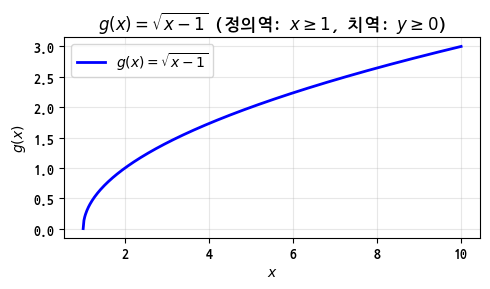

In [64]:
# 함수 그래프: g(x) = sqrt(x-1), 정의역 x>=1
x = np.linspace(1, 10, 500)
gx = np.sqrt(x - 1)

plt.figure(figsize=(5, 3))
plt.plot(x, gx, 'b-', lw=2, label=r'$g(x) = \sqrt{x-1}$')
plt.xlabel('$x$')
plt.ylabel('$g(x)$')
plt.title(r'$g(x) = \sqrt{x-1}$ (정의역: $x \geq 1$, 치역: $y \geq 0$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### IV.2 함수의 평행이동 및 대칭이동

- $x$축으로 $a$, $y$축으로 $b$ 평행이동: $y - b = f(x - a)$
- $x$축 대칭이동: $-y = f(x)$
- $y$축 대칭이동: $y = f(-x)$
- 원점 대칭이동: $-y = f(-x)$

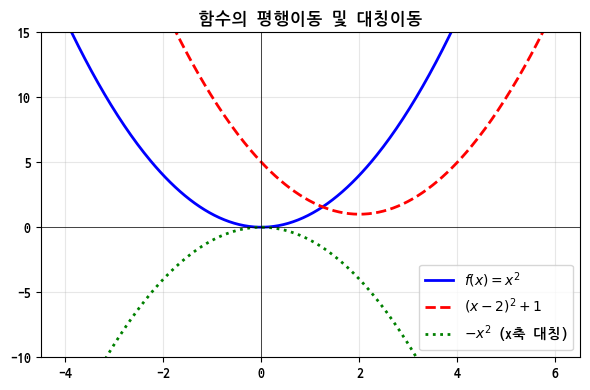

In [65]:
# f(x) = x^2 의 평행이동과 대칭이동 시각화
x = np.linspace(-4, 6, 300)

f = x**2                  # 원래 함수
f_shift = (x-2)**2 + 1   # x축으로 2, y축으로 1 평행이동
f_xsym = -x**2           # x축 대칭
f_ysym = (-x)**2         # y축 대칭 (y=x^2은 짝함수이므로 동일)

plt.figure(figsize=(6, 4))
plt.plot(x, f,       'b-',  lw=2, label=r'$f(x) = x^2$')
plt.plot(x, f_shift, 'r--', lw=2, label=r'$(x-2)^2 + 1$')
plt.plot(x, f_xsym,  'g:',  lw=2, label=r'$-x^2$ (x축 대칭)')
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.ylim(-10, 15)
plt.legend()
plt.title('함수의 평행이동 및 대칭이동')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### IV.3 합성함수

In [66]:
# 연습문제 2: f(x)=x^3+1, g(x)=sqrt(x+2)
def f(x):
    return x**3 + 1

def g(x):
    return np.sqrt(x + 2)

print("f(x) = x³+1,  g(x) = √(x+2)")
print(f"(g∘f)(2) = g(f(2)) = g({f(2)}) = {g(f(2)):.6f}")
print(f"(f∘g)(2) = f(g(2)) = f({g(2):.4f}) = {f(g(2)):.6f}")
print(f"(g∘g)(2) = g(g(2)) = g({g(2):.4f}) = {g(g(2)):.6f}")

f(x) = x³+1,  g(x) = √(x+2)
(g∘f)(2) = g(f(2)) = g(9) = 3.316625
(f∘g)(2) = f(g(2)) = f(2.0000) = 9.000000
(g∘g)(2) = g(g(2)) = g(2.0000) = 2.000000


**연습 4-1: 합성함수 심화**

딥러닝의 순전파(forward pass)는 합성함수의 연속입니다.

$h(x) = \sigma(w \cdot x + b)$ 형태의 뉴런 하나를 구현하고,
두 뉴런을 합성해 보세요.

입력 x = 2.0
뉴런 1 출력: h1 = σ(0.5·2.0 + -1.0) = σ(0.00) = 0.5000
뉴런 2 출력: h2 = σ(2.0·0.5000 + 0.5) = σ(1.5000) = 0.8176


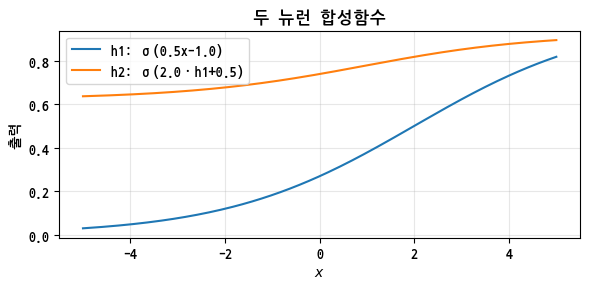

In [67]:
# 뉴런: h(x) = sigma(w*x + b)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def neuron(x, w, b):
    return sigmoid(w * x + b)

# 두 뉴런 합성
def two_layer(x, w1, b1, w2, b2):
    h1 = neuron(x, w1, b1)      # 첫 번째 뉴런
    h2 = neuron(h1, w2, b2)     # 두 번째 뉴런 (h1을 입력으로)
    return h2

x_val = 2.0
w1, b1 = 0.5, -1.0
w2, b2 = 2.0, 0.5

h1 = neuron(x_val, w1, b1)
h2 = two_layer(x_val, w1, b1, w2, b2)

print(f"입력 x = {x_val}")
print(f"뉴런 1 출력: h1 = σ({w1}·{x_val} + {b1}) = σ({w1*x_val+b1:.2f}) = {h1:.4f}")
print(f"뉴런 2 출력: h2 = σ({w2}·{h1:.4f} + {b2}) = σ({w2*h1+b2:.4f}) = {h2:.4f}")

# 입력값 범위에 따른 출력 변화 시각화
xs = np.linspace(-5, 5, 200)
plt.figure(figsize=(6, 3))
plt.plot(xs, neuron(xs, w1, b1), label=f'h1: σ({w1}x{b1:+})')
plt.plot(xs, two_layer(xs, w1, b1, w2, b2), label=f'h2: σ({w2}·h1{b2:+})')
plt.xlabel('$x$')
plt.ylabel('출력')
plt.title('두 뉴런 합성함수')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### IV.4 역함수

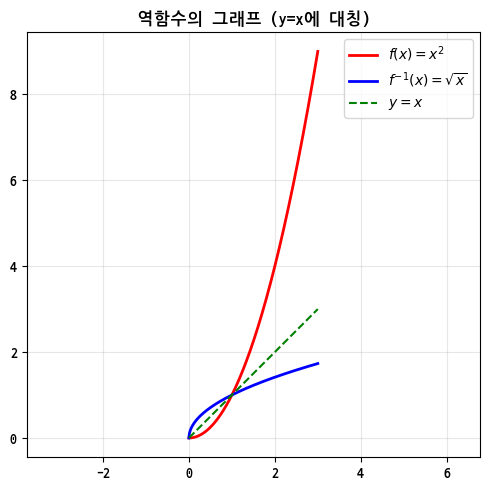

In [68]:
# 역함수의 그래프: y=x 직선에 대칭
def f1(x):
    return x**2

def f1_inv(x):
    return np.sqrt(x)

x = np.linspace(0, 3, 300)

plt.figure(figsize=(5, 5))
plt.plot(x, f1(x),     'r-',  lw=2, label=r'$f(x) = x^2$')
plt.plot(x, f1_inv(x), 'b-',  lw=2, label=r'$f^{-1}(x) = \sqrt{x}$')
plt.plot(x, x,          'g--', lw=1.5, label=r'$y = x$')
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.axis('equal')
plt.legend()
plt.title('역함수의 그래프 (y=x에 대칭)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### IV.5 데이터 과학에서 자주 사용되는 함수들

아래 함수들을 한 그래프에 비교해 봅니다.

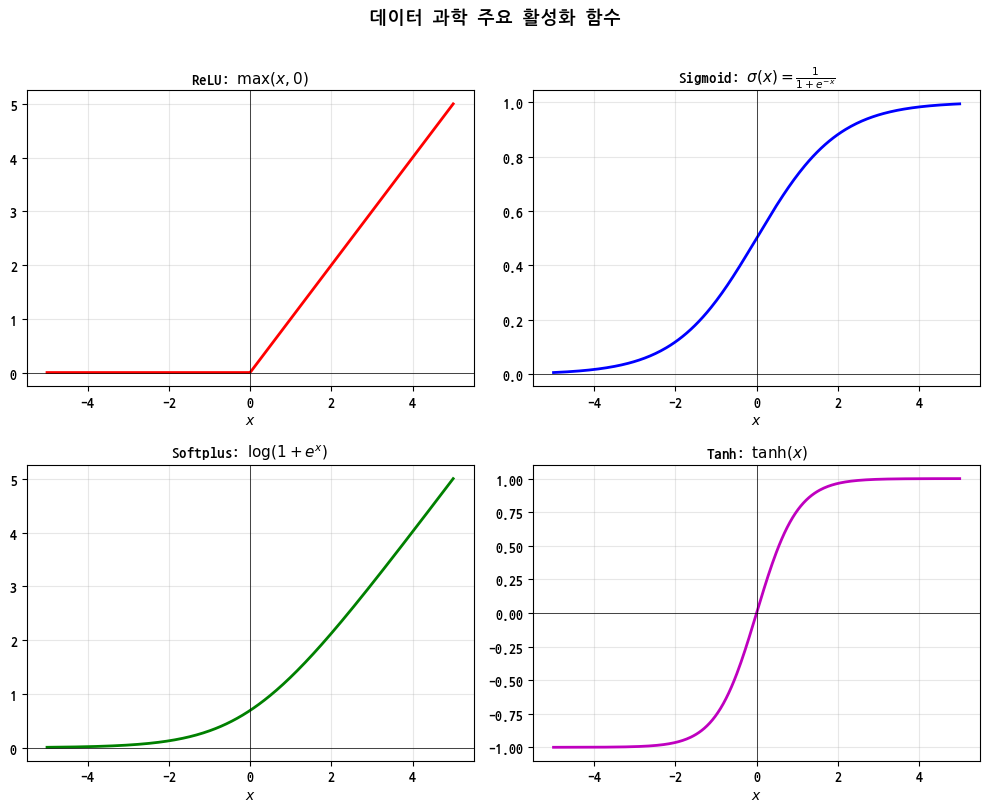

In [69]:
# 활성화 함수 비교: ReLU, Sigmoid, Softplus, Tanh
def relu(x):     return np.maximum(x, 0)
def sigmoid(x):  return 1 / (1 + np.exp(-x))
def softplus(x): return np.log(1 + np.exp(x))
def tanh(x):     return np.tanh(x)

xx = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

funcs = [
    (relu,     'ReLU: $\\max(x, 0)$',                 'r'),
    (sigmoid,  'Sigmoid: $\\sigma(x) = \\frac{1}{1+e^{-x}}$', 'b'),
    (softplus, 'Softplus: $\\log(1+e^x)$',             'g'),
    (tanh,     'Tanh: $\\tanh(x)$',                    'm'),
]

for ax, (func, title, color) in zip(axes.flat, funcs):
    ax.plot(xx, func(xx), color=color, lw=2)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)

plt.suptitle('데이터 과학 주요 활성화 함수', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

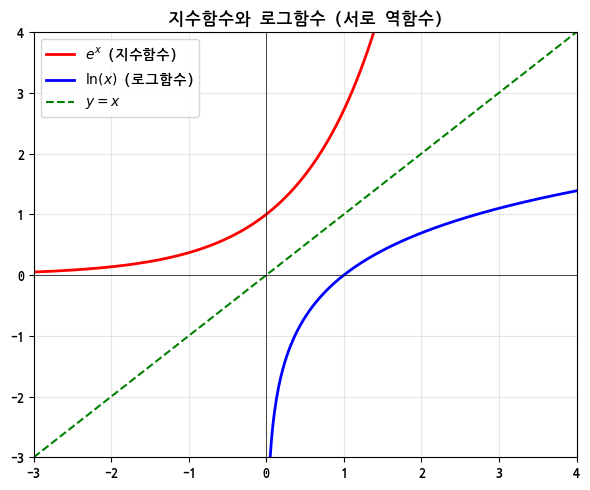

In [70]:
# 지수함수와 로그함수: 역함수 관계
x_pos = np.linspace(0.01, 4, 300)
x_all = np.linspace(-3, 4, 300)

plt.figure(figsize=(6, 5))
plt.plot(x_all, np.exp(x_all), 'r-',  lw=2, label=r'$e^x$ (지수함수)')
plt.plot(x_pos, np.log(x_pos), 'b-',  lw=2, label=r'$\ln(x)$ (로그함수)')
plt.plot(x_all, x_all,          'g--', lw=1.5, label=r'$y = x$')
plt.xlim(-3, 4)
plt.ylim(-3, 4)
plt.axhline(0, color='k', lw=0.5)
plt.axvline(0, color='k', lw=0.5)
plt.legend()
plt.title('지수함수와 로그함수 (서로 역함수)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### IV.6 다변수함수와 등고선

데이터 과학에서 손실함수(loss function)는 여러 파라미터를 입력으로 받는 다변수함수입니다.

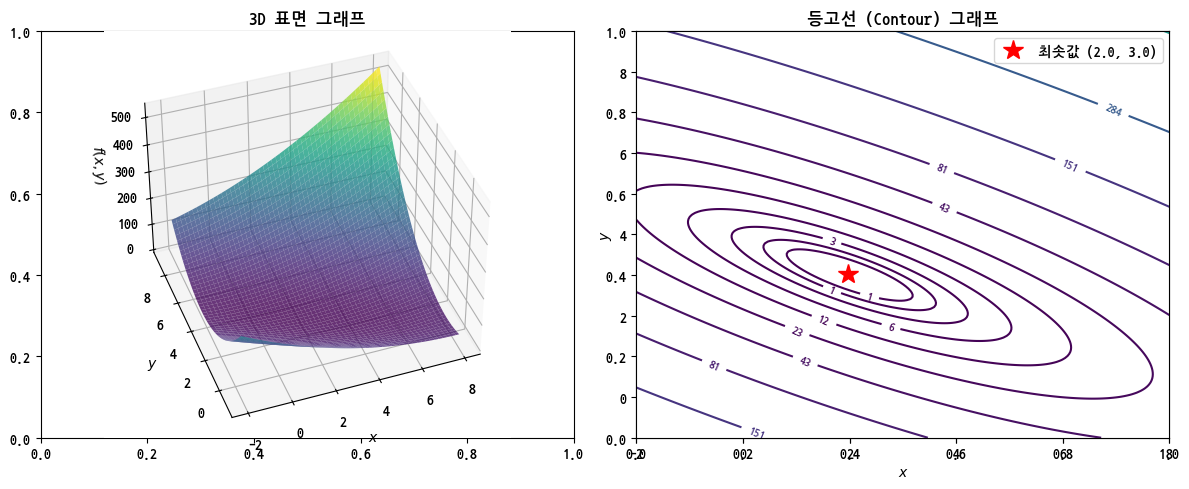

함수의 최솟값 위치: x≈1.97, y≈3.02, f≈0.00


In [71]:
# f(x, y) = 2x^2 + 6xy + 7y^2 - 26x - 54y + 107
def f(x, y):
    return 2*x**2 + 6*x*y + 7*y**2 - 26*x - 54*y + 107

xx = np.linspace(-2, 8, 200)
yy = np.linspace(-1, 9, 200)
X, Y = np.meshgrid(xx, yy)
Z = f(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 3D 표면
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, linewidth=0.1)
ax3d.view_init(40, -110)
ax3d.set_xlabel('$x$')
ax3d.set_ylabel('$y$')
ax3d.set_zlabel('$f(x,y)$')
ax3d.set_title('3D 표면 그래프')

# 등고선 (contour)
ax2d = fig.add_subplot(122)
CS = ax2d.contour(X, Y, Z, levels=np.logspace(0, 3, 12), cmap='viridis')
ax2d.clabel(CS, fmt='%d', fontsize=8)
ax2d.set_xlabel('$x$')
ax2d.set_ylabel('$y$')
ax2d.set_title('등고선 (Contour) 그래프')

# 최솟값 표시
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
x_min, y_min = xx[min_idx[1]], yy[min_idx[0]]
ax2d.plot(x_min, y_min, 'r*', ms=15, label=f'최솟값 ({x_min:.1f}, {y_min:.1f})')
ax2d.legend()

plt.tight_layout()
plt.show()
print(f"함수의 최솟값 위치: x≈{x_min:.2f}, y≈{y_min:.2f}, f≈{Z[min_idx]:.2f}")

---
### 종합 연습문제

**문제 1.** 다음을 파이썬으로 구현하고 확인하세요.

수열 $x_i: 1, 2, 3, 4$, 수열 $y_i: 0, 1, 0, 0$ 에 대해

$$\prod_{i=1}^{4} x_i^{y_i}$$

를 계산하라. $y_3 = 1$이고 나머지가 0이면 왜 $x_3$만 남는지 설명하라.

In [72]:
x = np.array([1, 2, 3, 4], dtype=float)
y = np.array([0, 1, 0, 0], dtype=float)

result = np.prod(x ** y)
print(f"수열 x = {x}")
print(f"수열 y = {y}")
print(f"x^y = {x**y}")  # 0^0=1, 1^1=1 등 확인
print(f"prod(x^y) = {result}")

# y3=1일 때
y2 = np.array([0, 0, 1, 0], dtype=float)  # 3번째만 1 (인덱스 2)
result2 = np.prod(x ** y2)
print(f"\ny = {y2} 일 때 prod(x^y) = {result2}  ← x[2] = {x[2]}")
print("∵ x^0 = 1이므로 곱에서 사라지고, x^1 = x 이므로 x_3만 남음")

수열 x = [1. 2. 3. 4.]
수열 y = [0. 1. 0. 0.]
x^y = [1. 2. 1. 1.]
prod(x^y) = 2.0

y = [0. 0. 1. 0.] 일 때 prod(x^y) = 3.0  ← x[2] = 3.0
∵ x^0 = 1이므로 곱에서 사라지고, x^1 = x 이므로 x_3만 남음


**문제 2.** 아래 손실함수 $L(w)$를 정의하고, $w \in [-3, 3]$ 범위에서 그래프를 그린 후 최솟값을 찾으세요.

$$L(w) = (w^2 - 3w + 2)^2$$

최솟값: L(0.998) = 0.000004
이론적 최솟값: w=1 또는 w=2 일 때 L=0


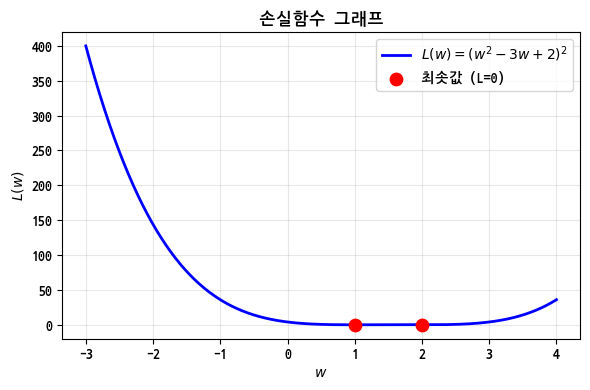

In [73]:
def L(w):
    return (w**2 - 3*w + 2)**2

w = np.linspace(-3, 4, 500)
loss = L(w)

# 최솟값 찾기
min_idx = np.argmin(loss)
print(f"최솟값: L({w[min_idx]:.3f}) = {loss[min_idx]:.6f}")
print(f"이론적 최솟값: w=1 또는 w=2 일 때 L=0")

plt.figure(figsize=(6, 4))
plt.plot(w, loss, 'b-', lw=2, label=r'$L(w) = (w^2-3w+2)^2$')
plt.scatter([1, 2], [0, 0], color='red', zorder=5, s=80, label='최솟값 (L=0)')
plt.xlabel('$w$')
plt.ylabel('$L(w)$')
plt.title('손실함수 그래프')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 요약

| 주제 | 핵심 내용 | 관련 함수 |
|------|----------|----------|
| 수학기호 | $\sum$, $\prod$, 그리스 문자 | `np.sum`, `np.prod` |
| 데이터 유형 | 스칼라→벡터→행렬→텐서 | `np.array` |
| 특수 행렬 | 영, 일, 대각, 항등, 대칭 | `np.zeros/ones/diag/identity` |
| 배열 생성 | 등간격/개수/로그스케일 | `arange/linspace/logspace` |
| 인덱싱 | 위치, 슬라이싱, 불린 | `[ ]`, `copy()` |
| 활성화 함수 | ReLU, Sigmoid, Softplus | `np.maximum`, `np.exp`, `np.log` |
| 합성/역함수 | $(g\circ f)(x)$, $f^{-1}$ | Python `def` |
| 다변수함수 | 3D 표면, 등고선 | `meshgrid`, `plot_surface`, `contour` |